# Optimal SVT Analysis

Notebook for quick experiments and visualization of the SVT method with *optimal* shrinkage.

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import matplotlib.pyplot as plt
import sys
from pathlib import Path
import seaborn as sns
import numpy as np

PROJECT_ROOT = Path.cwd().parent
IMAGE_PATH = Path(PROJECT_ROOT) / "data" / "CBSD68"
NETFLIX_PATH = Path(PROJECT_ROOT) / "data" / "netflix"
RESULTS_PATH = Path(PROJECT_ROOT) / "results" / "optimal_svt" 

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.svt.svt import svt
from src.optimal_svt.optimal_shrinkage import optimal_shrinkage_denoise, optimal_svt
from src.utils.masking import create_mask, apply_mask, create_netflix_mask
from src.utils.noise import add_gaussian_noise, add_pairflip_noise, add_symmetric_noise
from src.utils.io import load_image, load_netflix_matrix
from src.utils.metrics import mse, nmse, psnr

from experiments.config import *

## Images

In [8]:
def show_results(X, X_rec, X_noisy=None, X_masked=None, title=""):
    plt.figure(figsize=(12, 4))

    if X_noisy is not None:
        plt.subplot(1, 3, 1)
        plt.imshow(X, cmap="gray", vmin=0, vmax=1)
        plt.title("Original")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.imshow(X_noisy, cmap='gray', vmin=0, vmax=1)
        plt.title("Noisy")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.imshow(X_rec, cmap="gray", vmin=0, vmax=1)
        plt.title("Denoised")
        plt.axis("off")

    else:
        plt.subplot(1, 3, 1)
        plt.imshow(X, cmap='gray', vmin=0, vmax=255)
        plt.title("Original")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.imshow(X_masked, cmap='gray', vmin=0, vmax=255)
        plt.title("Observed pixels")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.imshow(X_rec, cmap='gray', vmin=0, vmax=255)
        plt.title("Reconstructed")
        plt.axis("off")

    plt.suptitle(title)
    plt.show()

### Option 1 - Apply optimal shrinkage post SVT

In [3]:
def svt_with_optimal_post(matrix_shape, Omega, b, tau, delta, sigma=None, **svt_kwargs):
    """
    Option 1:
    1) Run SVT
    2) Apply optimal shrinkage to the result
    """
    X_svt, history = svt(matrix_shape, Omega, b, tau, delta, **svt_kwargs)

    # Post-processing
    X_final = optimal_shrinkage_denoise(X_svt, sigma)

    return X_final, history

38.0 195.0 float64
Converged at iteration 287 with rank 186 and relative error 0.000010
Final rank: 186, final relative error: 0.000010
Optimal shrinkage rank: 112
NMSE: 0.00429892183237762
PSNR: 23.66640451620769


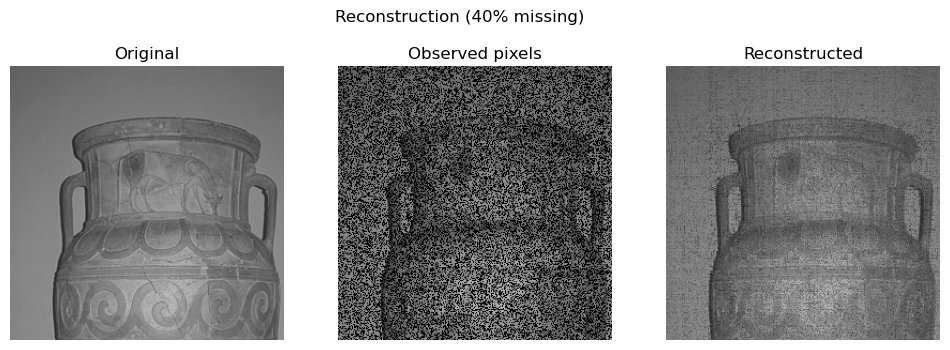

In [ ]:
# Reconstruction
X = load_image(IMAGE_PATH / "0047.png")
X = X[:256, :256]

n1, n2 = X.shape
missing_fraction = 0.4
observed_fraction = 1 - missing_fraction

tau = 8 * max(n1, n2)
delta = DELTA_FACTOR

mask = create_mask(X.shape, observed_fraction, seed=SEED)
Omega, b = apply_mask(X, mask)

X_masked = np.zeros_like(X)
X_masked[Omega] = b

X_rec, hist = svt_with_optimal_post(X.shape, Omega, b, tau, delta)
# print(np.max(X_rec), np.min(X_rec))
X_rec = np.clip(X_rec, 0, 255)

print("NMSE:", nmse(X, X_rec, data_range=255))
print("PSNR:", psnr(X, X_rec, data_range=255))

show_results(X, X_rec, X_masked=X_masked, title=f"Reconstruction ({missing_fraction*100:.0f}% missing)")

Image 47 Reconstruction with 60% observed entries:
- SVT only: 23.1099 PSNR
- Option 1 - applying optimal shrinkage post SVT (same parameters as baseline): **23.6664 PSNR**

Final rank: 67, final relative error: 0.132447
Optimal shrinkage rank: 67
NMSE: 0.006584010545547568
PSNR: 21.81509482189856


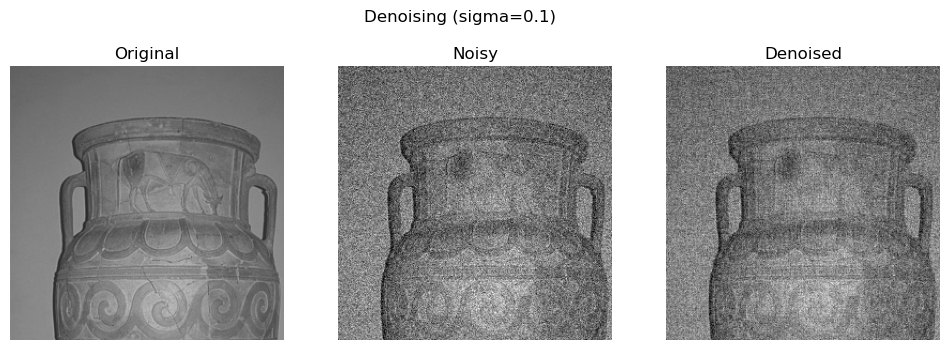

In [17]:
# Denoising
X = load_image(IMAGE_PATH / "0047.png", normalize=True)
X = X[:256, :256]

# sigma = 0.1 * 255  # sigma = 0.1 * 255 = 25.5
sigma = 0.1  # sigma = 0.1 in [0,1] range
X_noisy = add_gaussian_noise(X, sigma=sigma, normalize=True)

n1, n2 = X.shape
# tau = 2 * sigma * max(n1, n2)
tau = TAU_FACTOR * max(n1, n2) # tau = 5 * 256 = 1536
delta = DELTA_FACTOR

Omega = np.where(np.ones_like(X, dtype=bool))
b = X_noisy[Omega]

X_denoised, _ = svt_with_optimal_post(X.shape, Omega, b, tau, delta, sigma=sigma)
X_denoised = np.clip(X_denoised, 0, 1)

print("NMSE:", nmse(X, X_denoised, data_range=1.0))
print("PSNR:", psnr(X, X_denoised, data_range=1.0))

show_results(X, X_denoised, X_noisy=X_noisy, title="Denoising (sigma=0.1)")

Optimal shrinkage rank: 236
NMSE: 0.009902436158016606
PSNR: 20.042579488540383


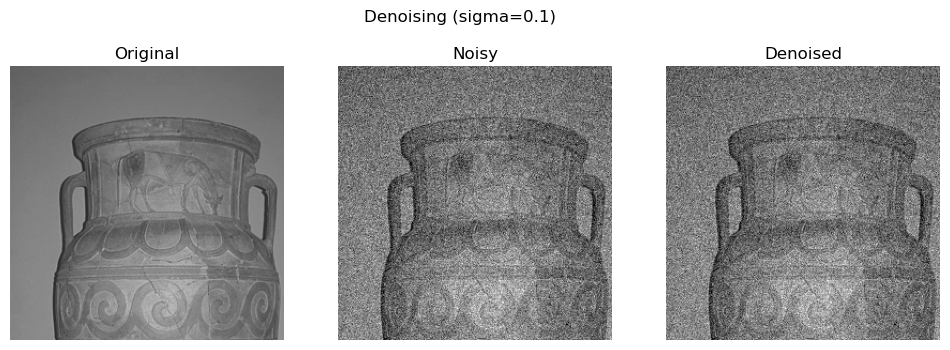

In [21]:
X = load_image(IMAGE_PATH / "0047.png", normalize=True)
X = X[:256, :256]

sigma = 0.1
X_noisy = add_gaussian_noise(X, sigma=sigma, normalize=True)

X_denoised = optimal_shrinkage_denoise(X_noisy, sigma=sigma) # known sigma
# X_denoised = optimal_shrinkage_denoise(X_noisy) # unknown sigma

X_denoised = np.clip(X_denoised, 0, 1)

print("NMSE:", nmse(X, X_denoised, data_range=1.0))
print("PSNR:", psnr(X, X_denoised, data_range=1.0))

show_results(X, X_denoised, X_noisy=X_noisy, title="Denoising (sigma=0.1)")

Optimal shrinkage rank: 91
NMSE: 0.004001509964557992
PSNR: 23.977760972887875


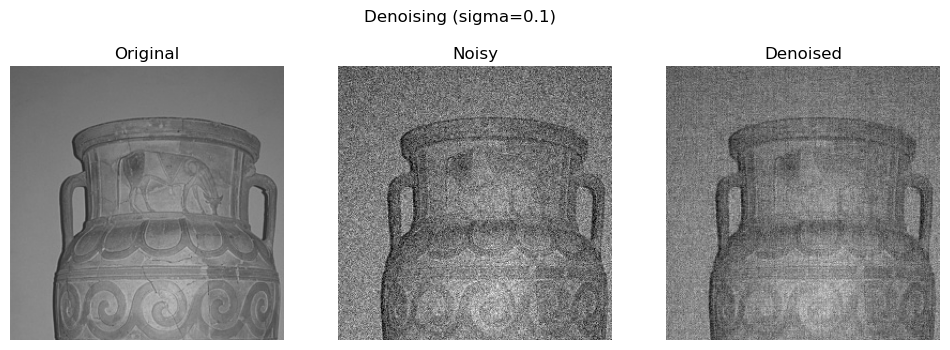

In [20]:
X = load_image(IMAGE_PATH / "0047.png", normalize=True)
X = X[:256, :256]

sigma = 0.1
X_noisy = add_gaussian_noise(X, sigma=sigma, normalize=True)

# X_denoised = optimal_shrinkage_denoise(X_noisy, sigma=sigma)
X_denoised = optimal_shrinkage_denoise(X_noisy) # unknown sigma

X_denoised = np.clip(X_denoised, 0, 1)

print("NMSE:", nmse(X, X_denoised, data_range=1.0))
print("PSNR:", psnr(X, X_denoised, data_range=1.0))

show_results(X, X_denoised, X_noisy=X_noisy, title="Denoising (sigma=0.1)")

Denoising Image 47 (normalized) with Gaussian noise with sigma = 0.1:
- SVT baseline: 21.8528 PSNR
- Denoising Option 1 - applying optimal shrinkage with the *known sigma* post SVT (same parameters as baseline): 21.8151 PSNR
- Denoising *without* SVT, using optimal shrinkage with the *known sigma*: 20.0426 PSNR
- Denoising *without* SVT, using optimal shrinkage with *unknown sigma* => sigma estimated from data: **23.9778 PSNR**


### Option 2 - Using optimal shrinkage inside SVT loop

Reconstruction with Option 2 fails. Denoising with Option 2 worked when sigma provided (not estimated), but PSNR value decreased to 19.9973.

38.0 195.0 float64
Final rank: 7, final relative error: 0.220036
NMSE: 0.010687207871543761
PSNR: 19.711357432822965


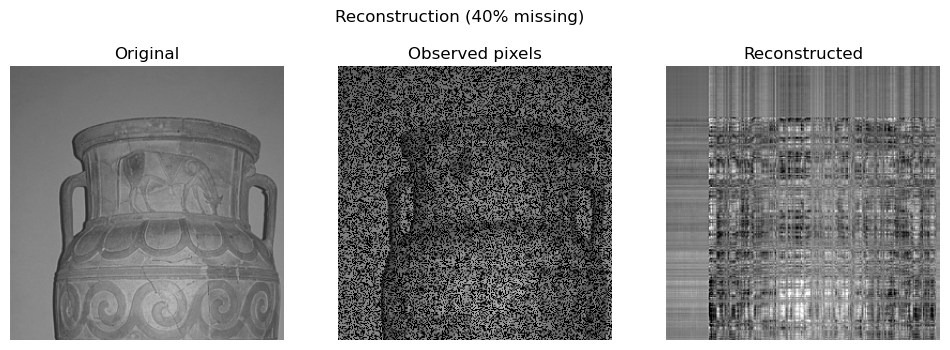

In [9]:
# Reconstruction
X = load_image(IMAGE_PATH / "0047.png")
X = X[:256, :256]
print(X.min(), X.max(), X.dtype)

n1, n2 = X.shape
missing_fraction = 0.4
observed_fraction = 1 - missing_fraction

tau = 8 * max(n1, n2) # tau = 8 * 256 = 2048  -> try 6, 7, 8  for tau factor?
# print(np.mean(X))
delta = DELTA_FACTOR # delta = 1.2 / 0.8 = 1.5

mask = create_mask(X.shape, observed_fraction, seed=SEED)
Omega, b = apply_mask(X, mask)

X_masked = np.zeros_like(X)
X_masked[Omega] = b

X_rec, hist = optimal_svt(X.shape, Omega, b, delta)
# print(np.max(X_rec), np.min(X_rec))
X_rec = np.clip(X_rec, 0, 255)

print("NMSE:", nmse(X, X_rec, data_range=255))
print("PSNR:", psnr(X, X_rec, data_range=255))

show_results(X, X_rec, X_masked=X_masked, title=f"Reconstruction ({missing_fraction*100:.0f}% missing)")

Final rank: 244, final relative error: 0.003557
NMSE: 0.010006298986002025
PSNR: 19.997265246356086


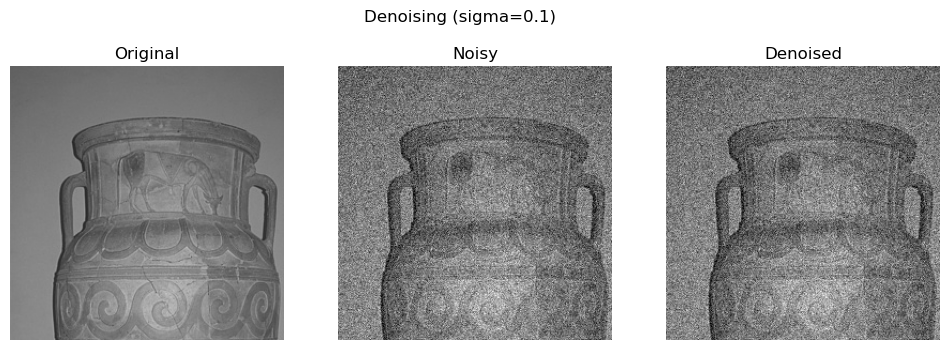

In [9]:
# Denoising
X = load_image(IMAGE_PATH / "0047.png", normalize=True)
X = X[:256, :256]

# sigma = 0.1 * 255  # sigma = 0.1 * 255 = 25.5
sigma = 0.1  # sigma = 0.1 in [0,1] range
X_noisy = add_gaussian_noise(X, sigma=sigma, normalize=True)
delta = DELTA_FACTOR

Omega = np.where(np.ones_like(X, dtype=bool))
b = X_noisy[Omega]

X_denoised, _ = optimal_svt(X.shape, Omega, b, delta, sigma=sigma)
X_denoised = np.clip(X_denoised, 0, 1)

print("NMSE:", nmse(X, X_denoised, data_range=1.0))
print("PSNR:", psnr(X, X_denoised, data_range=1.0))

show_results(X, X_denoised, X_noisy=X_noisy, title="Denoising (sigma=0.1)")

Final rank: 1, final relative error: 1.518490
NMSE: 0.15802527146055598
PSNR: 8.012734549554585


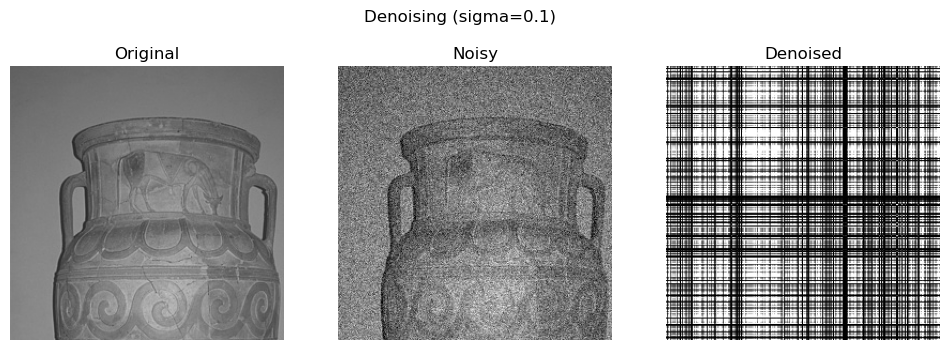

In [10]:
# Denoising
X = load_image(IMAGE_PATH / "0047.png", normalize=True)
X = X[:256, :256]

# sigma = 0.1 * 255  # sigma = 0.1 * 255 = 25.5
sigma = 0.1  # sigma = 0.1 in [0,1] range
X_noisy = add_gaussian_noise(X, sigma=sigma, normalize=True)
delta = DELTA_FACTOR

Omega = np.where(np.ones_like(X, dtype=bool))
b = X_noisy[Omega]

X_denoised, _ = optimal_svt(X.shape, Omega, b, delta, sigma=None) # unknown sigma
X_denoised = np.clip(X_denoised, 0, 1)

print("NMSE:", nmse(X, X_denoised, data_range=1.0))
print("PSNR:", psnr(X, X_denoised, data_range=1.0))

show_results(X, X_denoised, X_noisy=X_noisy, title="Denoising (sigma=0.1)")

## Recommender System Dataset

In [11]:
X, original_mask = load_netflix_matrix(
            NETFLIX_PATH / "netflix_dense_mtx_0_925_256_movies.csv"
    )

### Reconstruction

In [ ]:
# Reconstruction
n1, n2 = X.shape
tau = TAU_FACTOR * max(n1, n2) # tau = 5 * 4367 = 21835
missing_fraction = 0.4
observed_fraction = 1 - missing_fraction
delta = DELTA_FACTOR / observed_fraction
mask = create_netflix_mask(original_mask, observed_fraction, seed=SEED)

Omega, b = apply_mask(X, mask)
X_rec, _ = svt_with_optimal_post((n1, n2), Omega, b, tau, delta)
X_rec = np.clip(X_rec, 1, 5)

test_mask = original_mask & (~mask)

mse_val = np.mean((X[test_mask] - X_rec[test_mask]) ** 2)
psnr_val = psnr(X[test_mask], X_rec[test_mask], data_range=4.0)
rmse = np.sqrt(np.mean((X[test_mask] - X_rec[test_mask]) ** 2))
nrmse = rmse / 4.0  # divide by 4
mae = np.mean(np.abs(X[test_mask] - X_rec[test_mask]))

print(
        "Reconstruction for {}% observed entries:".format(int(observed_fraction * 100))
    )
print("MSE:", mse_val)
print("PSNR:", psnr_val)
print("RMSE:", rmse)
print("NRMSE:", nrmse)
print("MAE:", mae)

Final rank: 232, final relative error: 0.024131
Optimal shrinkage rank: 52
Reconstruction for 60% observed entries:
MSE: 0.5531702778399199
PSNR: 14.612611454863462
RMSE: 0.7437541783680411
NRMSE: 0.18593854459201029
MAE: 0.578494410677535


Netflix Reconstruction experiment for 60% observed entries: 
- SVT (Baseline): 0.7611 RMSE, 14.4126 PSNR
- **Option 1** - SVT + Opt Shrinkage Post (same parameters): **0.7438 RMSE, 14.6126 PSNR**

Option 2 (Optimal shrinkage within the SVT loop) also fails in the case for the reconstruction of the Netflix dataset.

In [17]:
# Reconstruction

n1, n2 = X.shape
tau = TAU_FACTOR * max(n1, n2) # tau = 5 * 4367 = 21835
missing_fraction = 0.4
observed_fraction = 1 - missing_fraction
delta = DELTA_FACTOR / observed_fraction
mask = create_netflix_mask(original_mask, observed_fraction, seed=SEED)

Omega, b = apply_mask(X, mask)
X_rec, _ = optimal_svt(X.shape, Omega, b, delta)
X_rec = np.clip(X_rec, 1, 5)

test_mask = original_mask & (~mask)

mse_val = np.mean((X[test_mask] - X_rec[test_mask]) ** 2)
psnr_val = psnr(X[test_mask], X_rec[test_mask], data_range=4.0)
rmse = np.sqrt(np.mean((X[test_mask] - X_rec[test_mask]) ** 2))
nrmse = rmse / 4.0  # divide by 4
mae = np.mean(np.abs(X[test_mask] - X_rec[test_mask]))

print(
        "Reconstruction for {}% observed entries:".format(int(observed_fraction * 100))
    )
print("MSE:", mse_val)
print("PSNR:", psnr_val)
print("RMSE:", rmse)
print("NRMSE:", nrmse)
print("MAE:", mae)

d:\Projects\nuclear-norm-thesis\nuclear-norm-data-reconstruction\src\optimal_svt\optimal_shrinkage.py:23: RuntimeWarning: invalid value encountered in divide
  y = S / sigma


Final rank: 1, final relative error: 0.834785
Reconstruction for 60% observed entries:
MSE: 3.5959327239406718
PSNR: 6.483084247044789
RMSE: 1.8962944718425647
NRMSE: 0.4740736179606412
MAE: 1.535206881644934


### Denoising

#### Option 1

In [12]:
# Denoising experiment with symmetric noise on the observed entries

n1, n2 = X.shape
tau = 7 * max(n1, n2) # tau = 5 * 4367 = 21835
delta = DELTA_FACTOR
Y, flip_mask = add_symmetric_noise(X, original_mask, prob=0.1)
Omega = np.where(original_mask)  # use observed entries
b = Y[Omega]

X_rec, _ = svt_with_optimal_post((n1, n2), Omega, b, tau, delta) # unknown sigma
X_rec = np.clip(X_rec, 1, 5)

rmse_corrupted_before = np.sqrt(
np.mean((X[flip_mask]-Y[flip_mask])**2)
)
print("Corrupted entries RMSE (before denoising):", rmse_corrupted_before)
rmse_noisy = np.sqrt(
np.mean((X[original_mask]-Y[original_mask])**2)
)
print("Noisy observed entries RMSE:", rmse_noisy)

rmse = np.sqrt(np.mean(
        (X[original_mask] - X_rec[original_mask]) ** 2
    ))
print("Denoising with 10% symmetric noise on observed entries:")
print(f"RMSE: {rmse:.4f}")

rmse_corrupted_after = np.sqrt(
np.mean((X[flip_mask]-X_rec[flip_mask])**2)
)
print("Corrupted entries RMSE (after denoising):", rmse_corrupted_after)

Final rank: 177, final relative error: 0.103792
Optimal shrinkage rank: 21
Corrupted entries RMSE (before denoising): 2.114228795991116
Noisy observed entries RMSE: 0.6688514341084421
Denoising with 10% symmetric noise on observed entries:
RMSE: 0.7326
Corrupted entries RMSE (after denoising): 0.7851670437298092


In [14]:
clean_mask = original_mask & (~flip_mask)
mse_clean = np.mean(
        (X[clean_mask] - X_rec[clean_mask]) ** 2
)  # did we damage correct entries?
rmse_clean = np.sqrt(mse_clean)

print("Clean entries RMSE:", rmse_clean)

Clean entries RMSE: 0.7265178154107982


Netflix Denoising Experiment with symmetric noise with 10% probability:
- SVT (Baseline): 0.66 RMSE, 1.77 corrupted entries RMSE (after denoising), 0.3615 clean entries RMSE (after denoising)
- **Option 1** - SVT + Opt Shrinkage Post (same parameters): 0.7341 RMSE, **0.784 corrupted entries RMSE**, 0.7265 clean entries RMSE (after denoising)

In [19]:
# Denoising experiment with symmetric noise on the observed entries

n1, n2 = X.shape
tau = 7 * max(n1, n2) # tau = 5 * 4367 = 21835
delta = DELTA_FACTOR
Y, flip_mask = add_symmetric_noise(X, original_mask, prob=0.1)
Omega = np.where(original_mask)  # use observed entries
b = Y[Omega]

X_rec, _ = svt_with_optimal_post((n1, n2), Omega, b, tau, delta, sigma = 0.1)
X_rec = np.clip(X_rec, 1, 5)

rmse_corrupted_before = np.sqrt(
np.mean((X[flip_mask]-Y[flip_mask])**2)
)
print("Corrupted entries RMSE (before denoising):", rmse_corrupted_before)
rmse_noisy = np.sqrt(
np.mean((X[original_mask]-Y[original_mask])**2)
)
print("Noisy observed entries RMSE:", rmse_noisy)

rmse = np.sqrt(np.mean(
        (X[original_mask] - X_rec[original_mask]) ** 2
    ))
print("Denoising with 10% symmetric noise on observed entries:")
print(f"RMSE: {rmse:.4f}")

rmse_corrupted_after = np.sqrt(
np.mean((X[flip_mask]-X_rec[flip_mask])**2)
)
print("Corrupted entries RMSE (after denoising):", rmse_corrupted_after)

Final rank: 179, final relative error: 0.102625
Optimal shrinkage rank: 179
Corrupted entries RMSE (before denoising): 2.1221981607706777
Noisy observed entries RMSE: 0.6711521374559334
Denoising with 10% symmetric noise on observed entries:
RMSE: 0.6606
Corrupted entries RMSE (after denoising): 1.7863911366002896


If sigma is given as $0.1$, the probability used in the symmetric noise, the results for RMSE are almost identical as the standard SVT denoising (=no change with using optimal shrinkage after the SVT denoising).

In [21]:
Y, flip_mask = add_symmetric_noise(X, original_mask, prob=0.1)

# X_rec = optimal_shrinkage_denoise(X_noisy, sigma=sigma)
X_rec = optimal_shrinkage_denoise(Y) # unknown sigma

X_rec = np.clip(X_rec, 1, 5)

rmse_corrupted_before = np.sqrt(
np.mean((X[flip_mask]-Y[flip_mask])**2)
)
print("Corrupted entries RMSE (before denoising):", rmse_corrupted_before)
rmse_noisy = np.sqrt(
np.mean((X[original_mask]-Y[original_mask])**2)
)
print("Noisy observed entries RMSE:", rmse_noisy)

rmse = np.sqrt(np.mean(
        (X[original_mask] - X_rec[original_mask]) ** 2
    ))
print("Denoising with 10% symmetric noise on observed entries:")
print(f"RMSE: {rmse:.4f}")

rmse_corrupted_after = np.sqrt(
np.mean((X[flip_mask]-X_rec[flip_mask])**2)
)
print("Corrupted entries RMSE (after denoising):", rmse_corrupted_after)

Optimal shrinkage rank: 27
Corrupted entries RMSE (before denoising): 2.115557076682418
Noisy observed entries RMSE: 0.6680555276453218
Denoising with 10% symmetric noise on observed entries:
RMSE: 0.7668
Corrupted entries RMSE (after denoising): 0.8421225656118033


In [22]:
Y, flip_mask = add_symmetric_noise(X, original_mask, prob=0.1)

# X_rec = optimal_shrinkage_denoise(X_noisy, sigma=sigma)
X_rec = optimal_shrinkage_denoise(Y, sigma=0.1) # known sigma

X_rec = np.clip(X_rec, 1, 5)

rmse_corrupted_before = np.sqrt(
np.mean((X[flip_mask]-Y[flip_mask])**2)
)
print("Corrupted entries RMSE (before denoising):", rmse_corrupted_before)
rmse_noisy = np.sqrt(
np.mean((X[original_mask]-Y[original_mask])**2)
)
print("Noisy observed entries RMSE:", rmse_noisy)

rmse = np.sqrt(np.mean(
        (X[original_mask] - X_rec[original_mask]) ** 2
    ))
print("Denoising with 10% symmetric noise on observed entries:")
print(f"RMSE: {rmse:.4f}")

rmse_corrupted_after = np.sqrt(
np.mean((X[flip_mask]-X_rec[flip_mask])**2)
)
print("Corrupted entries RMSE (after denoising):", rmse_corrupted_after)

Optimal shrinkage rank: 256
Corrupted entries RMSE (before denoising): 2.1178417816270896
Noisy observed entries RMSE: 0.6701981961358099
Denoising with 10% symmetric noise on observed entries:
RMSE: 0.6702
Corrupted entries RMSE (after denoising): 2.1178380050166137


- Optimal Shrinkage Denoiser only (sigma not given): 0.7668 RMSE, 0.8421 corrupted entries RMSE
- Optimal Shrinkage Denoiser only (sigma given): no effect

#### Option 2

In [26]:
# Denoising experiment with symmetric noise on the observed entries

# 1: Start with real observed Netflix matrix with 92.5% observed entries
n1, n2 = X.shape
tau = 7 * max(n1, n2) # tau = 5 * 4367 = 21835
delta = DELTA_FACTOR

# 2: Corrupt the dataset
Y, flip_mask = add_symmetric_noise(X, original_mask, prob=0.1) # add symmetric noise to the observed entries in X to create Y
Omega = np.where(original_mask)  # use observed entries
b = Y[Omega]

rmse_corrupted_before = np.sqrt(
np.mean((X[flip_mask]-Y[flip_mask])**2)
)
print("Corrupted entries RMSE (before denoising):", rmse_corrupted_before)
rmse_noisy = np.sqrt(
np.mean((X[original_mask]-Y[original_mask])**2)
)
print("Noisy observed entries RMSE:", rmse_noisy)

# 3: Run recovery using SVT
X_rec, _ = optimal_svt((n1, n2), Omega, b, delta, sigma=0.1) # known sigma
X_rec = np.clip(X_rec, 1, 5)

rmse = np.sqrt(np.mean(
        (X[original_mask] - X_rec[original_mask]) ** 2
    ))
print("Denoising with 10% symmetric noise on observed entries:")
print(f"RMSE: {rmse:.4f}")

rmse_corrupted_after = np.sqrt(
np.mean((X[flip_mask]-X_rec[flip_mask])**2)
)
print("Corrupted entries RMSE (after denoising):", rmse_corrupted_after)

Corrupted entries RMSE (before denoising): 2.1210458704461255
Noisy observed entries RMSE: 0.6693829564514417
Final rank: 256, final relative error: 0.000003
Denoising with 10% symmetric noise on observed entries:
RMSE: 0.6694
Corrupted entries RMSE (after denoising): 2.121045583707425


Optimal shrinkage within the SVT loop *(unknown sigma) = fails*; Optimal shrinkage within the SVT loop *(sigma as $0.1$ for the prob.) = no effect*

In [38]:
# Try Gaussian noise instead of symmetric noise for the Netflix denoising
rng = np.random.default_rng(seed=SEED)
sigma = 0.6
noise = sigma * rng.standard_normal(X[original_mask].shape)
Y = X.copy()
Y[original_mask] = X[original_mask] + noise
Y = np.clip(Y, 1, 5)

X_rec = optimal_shrinkage_denoise(Y, sigma=sigma)
# X_rec = optimal_shrinkage_denoise(Y) # unknown sigma

X_rec = np.clip(X_rec, 1, 5)

rmse_corrupted_before = np.sqrt(
np.mean((X[flip_mask]-Y[flip_mask])**2)
)
print("Corrupted entries RMSE (before denoising):", rmse_corrupted_before)
rmse_noisy = np.sqrt(
np.mean((X[original_mask]-Y[original_mask])**2)
)
print("Noisy observed entries RMSE:", rmse_noisy)

rmse = np.sqrt(np.mean(
        (X[original_mask] - X_rec[original_mask]) ** 2
    ))
print("Denoising with 10% symmetric noise on observed entries:")
print(f"RMSE: {rmse:.4f}")

rmse_corrupted_after = np.sqrt(
np.mean((X[flip_mask]-X_rec[flip_mask])**2)
)
print("Corrupted entries RMSE (after denoising):", rmse_corrupted_after)

Optimal shrinkage rank: 256
Corrupted entries RMSE (before denoising): 0.5416878536361172
Noisy observed entries RMSE: 0.5443039761014972
Denoising with 10% symmetric noise on observed entries:
RMSE: 0.5443
Corrupted entries RMSE (after denoising): 0.5416493208524351
